# Week 5 — Newton/IRLS and a Metropolis Sampler

*INFO 521 worked notebook (Module 5). Companion to lectures m5a/m5b. Needs the course
environment (`info521` package).*

Binarize the outcome — hypertensive or not — and conjugacy breaks: no closed-form
posterior survives. This notebook does the whole Module-5 arc on real patients:
**Newton–Raphson** finds the logistic MLE in a handful of steps; on a small cohort we then
compare the **exact** posterior (brute-force grid), its **Laplace** Gaussian, and
**Metropolis** samples.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from info521.data import load_clinical, primary_predictor, hypertension

BLUE, VERMILLION, GREEN, ORANGE, SKY = "#0072B2", "#D55E00", "#009E73", "#E69F00", "#56B4E9"
rng = np.random.default_rng(521)

ds = load_clinical()
age = primary_predictor(ds)
z   = (age - age.mean()) / age.std()
labels, _ = hypertension(ds)
X = np.column_stack([np.ones_like(z), z]); N = len(labels)

def sigmoid(a): return 1/(1 + np.exp(-a))

## Newton–Raphson on all 5,102 patients

Gradient $\mathbf{X}^\top(\mathbf{y}-\boldsymbol{\mu})$, Hessian
$-\mathbf{X}^\top\mathbf{R}\mathbf{X}$ with $\mathbf{R} = \mathrm{diag}(\mu_n(1-\mu_n))$ —
one linear solve per step, no learning rate.

converged in 4 iterations: ŵ = [-0.487  0.519]
per-SD-of-age odds ratio: e^0.519 = 1.68


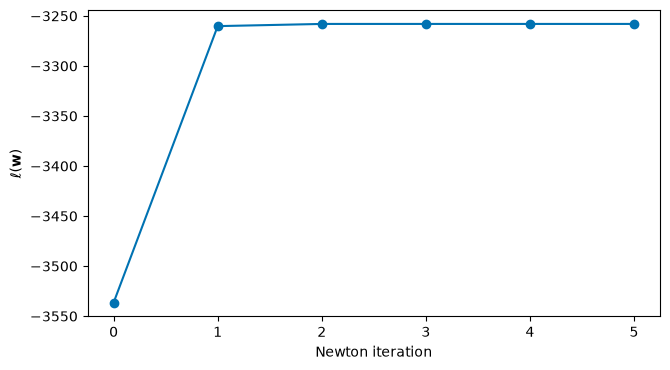

In [2]:
def loglik(w):
    a = X @ w
    return float((labels*a - np.logaddexp(0.0, a)).sum())

w = np.zeros(2); path = [w.copy()]
for it in range(25):
    p = sigmoid(X @ w)
    g = X.T @ (labels - p)
    H = -(X * (p*(1-p))[:, None]).T @ X
    step = np.linalg.solve(H, -g)
    w = w + step; path.append(w.copy())
    if np.abs(step).max() < 1e-10: break
w_mle = w
print(f"converged in {it} iterations: ŵ = {w_mle.round(3)}")
print(f"per-SD-of-age odds ratio: e^{w_mle[1]:.3f} = {np.exp(w_mle[1]):.2f}")

lls = [loglik(wi) for wi in path]
fig, ax = plt.subplots(figsize=(6.8, 3.8))
ax.plot(range(len(lls)), lls, "o-", color=BLUE)
ax.set_xlabel("Newton iteration"); ax.set_ylabel("$\\ell(\\mathbf{w})$")
plt.tight_layout(); plt.show()

## A tiny cohort, so the approximations have something to miss

With all 5,102 patients every method agrees. Take **25 real patients** (seed 521) and a
Gaussian prior $\mathbf{w} \sim \mathcal{N}(\mathbf{0}, \tau^2\mathbf{I})$, $\tau = 2$ —
small-sample posteriors are visibly non-Gaussian.

In [3]:
sub = rng.choice(N, 25, replace=False)
Xs, ys = X[sub], labels[sub].astype(float)
TAU2 = 4.0

def log_post(w):
    a = Xs @ w
    return float((ys*a - np.logaddexp(0.0, a)).sum() - (w @ w)/(2*TAU2))

# MAP + Laplace: Newton on the penalized objective; A = −Hessian at the peak
w = np.zeros(2)
for _ in range(50):
    p = sigmoid(Xs @ w)
    g = Xs.T @ (ys - p) - w/TAU2
    A = (Xs * (p*(1-p))[:, None]).T @ Xs + np.eye(2)/TAU2
    step = np.linalg.solve(A, g)
    w = w + step
    if np.abs(step).max() < 1e-12: break
w_map, S_lap = w, np.linalg.inv(A)
print("MAP:", w_map.round(3))

MAP: [0.173 0.788]


In [4]:
# Exact posterior on a 2-D grid (feasible ONLY because D = 2) → marginal of the slope
sd = np.sqrt(np.diag(S_lap))
g0 = np.linspace(w_map[0]-5*sd[0], w_map[0]+5*sd[0], 200)
g1 = np.linspace(w_map[1]-5*sd[1], w_map[1]+5*sd[1], 200)
LP = np.array([[log_post(np.array([a0, a1])) for a0 in g0] for a1 in g1])
P  = np.exp(LP - LP.max())
P /= P.sum() * (g0[1]-g0[0]) * (g1[1]-g1[0])
marg1 = P.sum(axis=1) * (g0[1]-g0[0])
lap1  = np.exp(-(g1-w_map[1])**2/(2*S_lap[1,1])) / np.sqrt(2*np.pi*S_lap[1,1])

## Metropolis: ratios cancel the normalizer

Propose $\mathbf{w}' \sim \mathcal{N}(\mathbf{w}, s^2\mathbf{I})$; accept with probability
$\min(1, \tilde{p}(\mathbf{w}')/\tilde{p}(\mathbf{w}))$ — the unknown evidence cancels in
the ratio.

acceptance rate: 0.27


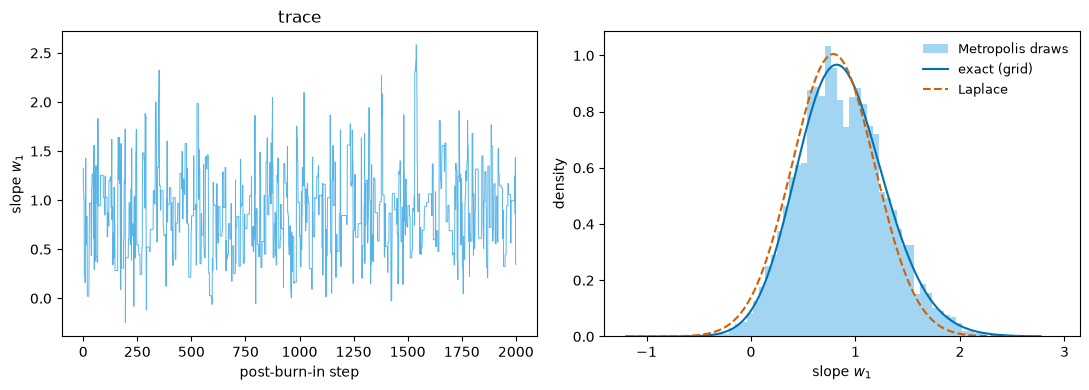

In [5]:
steps, s = 24000, 0.9
w, lp = w_map.copy(), log_post(w_map)
chain = np.empty((steps, 2)); acc = 0
for t in range(steps):
    w_prop = w + rng.normal(0, s, size=2)
    lp_prop = log_post(w_prop)
    if np.log(rng.uniform()) < lp_prop - lp:
        w, lp = w_prop, lp_prop; acc += 1
    chain[t] = w
draws1 = chain[2000:, 1]                      # drop burn-in
print(f"acceptance rate: {acc/steps:.2f}")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))
axL.plot(draws1[:2000], color=SKY, lw=0.7)
axL.set_xlabel("post-burn-in step"); axL.set_ylabel("slope $w_1$"); axL.set_title("trace")
axR.hist(draws1, bins=60, density=True, color=SKY, alpha=0.55, label="Metropolis draws")
axR.plot(g1, marg1, color=BLUE, label="exact (grid)")
axR.plot(g1, lap1, "--", color=VERMILLION, label="Laplace")
axR.set_xlabel("slope $w_1$"); axR.set_ylabel("density")
axR.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

The draw histogram reproduces the exact posterior's **skew** — the shape the symmetric
Laplace Gaussian misses. Laplace's error shrinks with *data*; Monte Carlo's shrinks with
*compute*.

**Try it yourself:** re-run Metropolis with `s = 0.05` and `s = 10`. Watch the trace turn
into a slow drift (tiny steps) or a staircase (mass rejection) — then check the acceptance
rate against the 20–50% rule of thumb.